<a href="https://colab.research.google.com/github/Panini783/machineLearn/blob/main/%D0%9B%D0%914_%D0%A1%D0%BB%D1%8E%D1%81%D0%B0%D1%80_%D0%A4%D0%86%D0%A23_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Лабораторна робота №4. Регресійні моделі: глибоке дослідження

**Датасет:** Car Price Prediction Multiple Linear Regression  
https://www.kaggle.com/datasets/hellbuoy/car-price-prediction?select=CarPrice_Assignment.csv

**Мета роботи:** виконати підготовку даних, побудувати та порівняти регресійні моделі для прогнозування ціни автомобіля, оцінити їх якість і проаналізувати отримані результати.

> У шаблоні наведено лише умови завдань. Реалізацію необхідно виконати самостійно у порожніх комірках.


## 1. Завантаження та первинний аналіз даних

Завантажити датасет та виконати його первинний огляд:
- визначити кількість об'єктів і ознак;
- переглянути назви стовпців;
- визначити типи даних;
- визначити цільову змінну;
- вивести основні статистичні характеристики даних.


In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files

uploaded = files.upload()

file_name = list(uploaded.keys())[0]

df = pd.read_csv(file_name)

print(f"Кількість об'єктів (рядків): {df.shape[0]}")
print(f"Кількість ознак (стовпчиків): {df.shape[1]}")

Saving CarPrice_Assignment.csv to CarPrice_Assignment (1).csv
Кількість об'єктів (рядків): 205
Кількість ознак (стовпчиків): 26


## 2. Перевірка якості даних

Перевірити:
- наявність пропущених значень;
- наявність повних дублікатів;
- кількість унікальних значень в ознаках.

Під час аналізу врахувати, що `car_ID` є унікальним ідентифікатором автомобіля і сам по собі не повинен використовуватися для визначення дублікатів за змістовими характеристиками.


In [25]:
print("Пропущені значення у стовпчиках:")
print(df.isnull().sum())

duplicates = df.drop(columns=['car_ID']).duplicated().sum()
print(f"\nКількість дублікатів (без car_ID): {duplicates}")

print("\nКількість унікальних значень у кожній ознаці:")
print(df.nunique())

Пропущені значення у стовпчиках:
car_ID              0
symboling           0
CarName             0
fueltype            0
aspiration          0
doornumber          0
carbody             0
drivewheel          0
enginelocation      0
wheelbase           0
carlength           0
carwidth            0
carheight           0
curbweight          0
enginetype          0
cylindernumber      0
enginesize          0
fuelsystem          0
boreratio           0
stroke              0
compressionratio    0
horsepower          0
peakrpm             0
citympg             0
highwaympg          0
price               0
dtype: int64

Кількість дублікатів (без car_ID): 0

Кількість унікальних значень у кожній ознаці:
car_ID              205
symboling             6
CarName             147
fueltype              2
aspiration            2
doornumber            2
carbody               5
drivewheel            3
enginelocation        2
wheelbase            53
carlength            75
carwidth             44
carheight

## 3. Робота з car_ID

Зберегти `car_ID` окремо для подальшої ідентифікації автомобілів у результатах прогнозування.  
Не використовувати `car_ID` як ознаку під час навчання моделей.


In [26]:
car_ids = df['car_ID']

df_features = df.drop(columns=['car_ID'])

## 4. Дослідження розподілів числових ознак

Дослідити розподіли числових ознак:
- побудувати відповідні графіки;
- обчислити коефіцієнти асиметрії;
- визначити ознаки з найбільш вираженою асиметрією;
- коротко прокоментувати отримані результати.


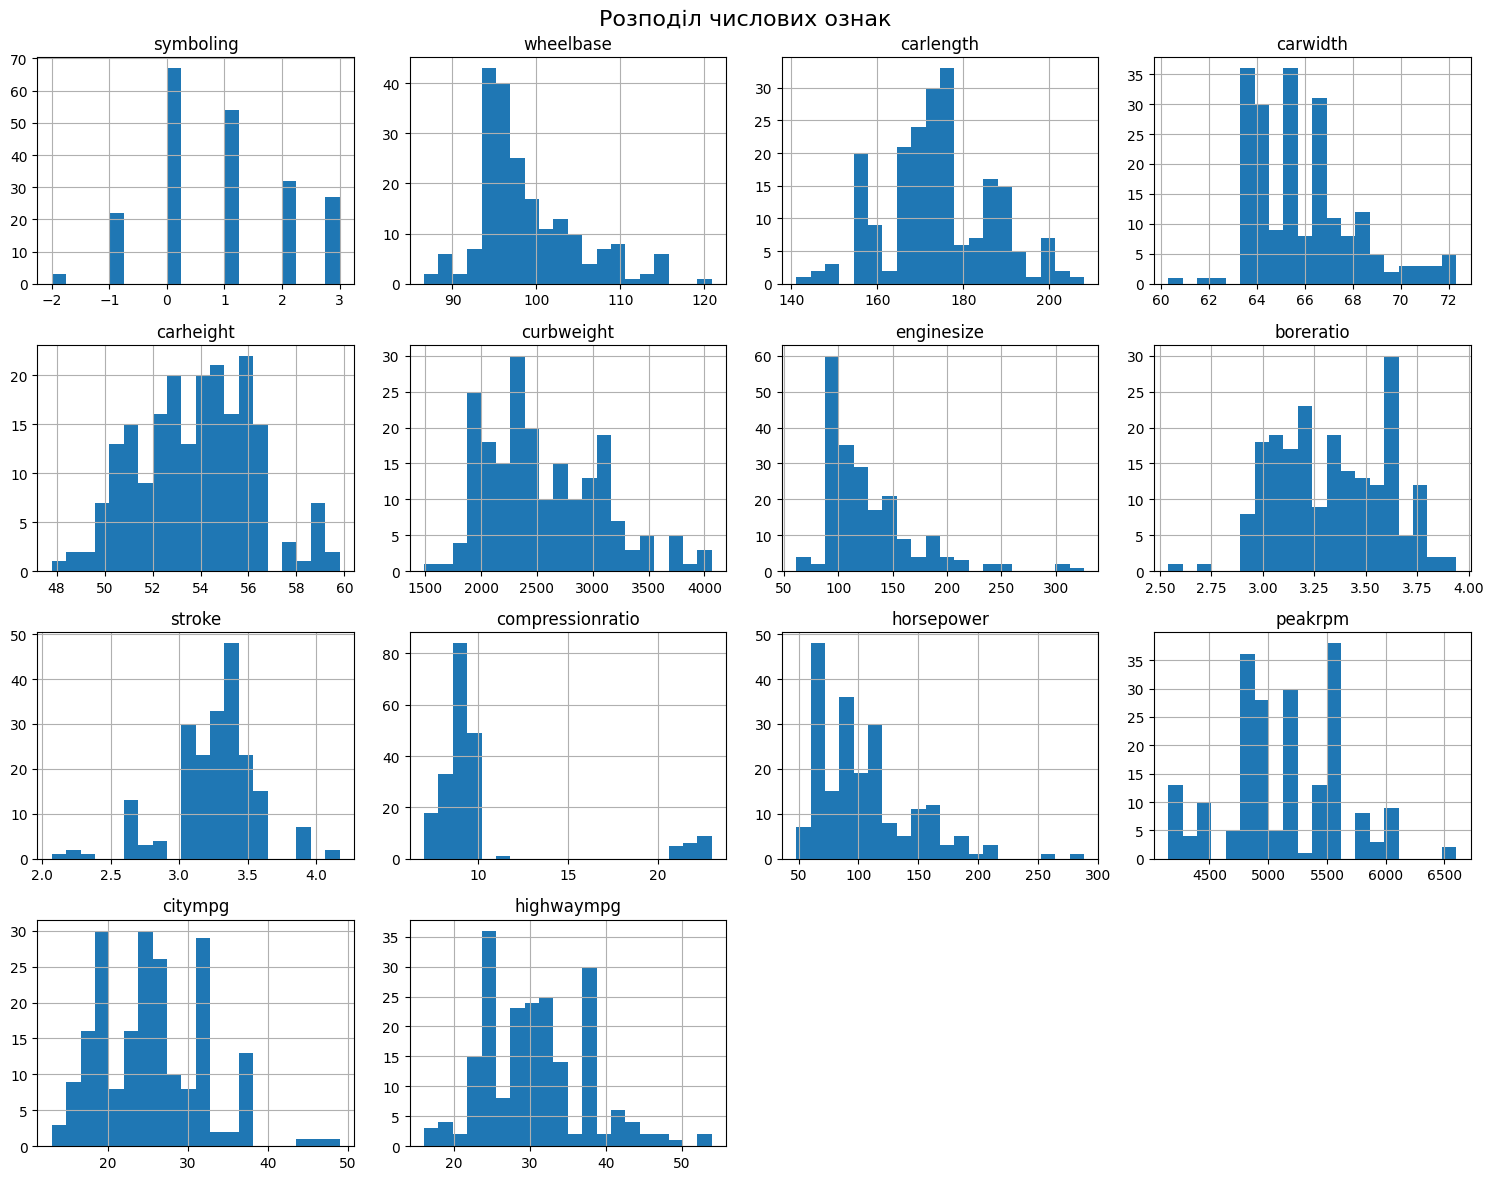

Коефіцієнти асиметрії числових ознак:
compressionratio    2.610862
enginesize          1.947655
horsepower          1.405310
wheelbase           1.050214
carwidth            0.904003
curbweight          0.681398
citympg             0.663704
highwaympg          0.539997
symboling           0.211072
carlength           0.155954
peakrpm             0.075159
carheight           0.063123
boreratio           0.020156
stroke             -0.689705
dtype: float64

Ознаки з найбільш вираженою асиметрією (|skew| > 1):
wheelbase           1.050214
enginesize          1.947655
compressionratio    2.610862
horsepower          1.405310
dtype: float64


In [27]:
numeric_cols = df_features.select_dtypes(include=[np.number]).columns.drop('price')

df_features[numeric_cols].hist(bins=20, figsize=(15, 12))
plt.suptitle("Розподіл числових ознак", fontsize=16)
plt.tight_layout()
plt.show()

skewness = df_features[numeric_cols].skew()
print("Коефіцієнти асиметрії числових ознак:")
print(skewness.sort_values(ascending=False))

high_skew = skewness[abs(skewness) > 1]
print(f"\nОзнаки з найбільш вираженою асиметрією (|skew| > 1):\n{high_skew}")

## 5. Формування train/test вибірок

Відокремити цільову змінну `price` від ознак та розділити дані на:
- навчальну вибірку — 80%;
- тестову вибірку — 20%.

Забезпечити відтворюваність поділу.  
Окремо зберегти `car_ID` для об'єктів, які потрапили до train і test.

**Важливо:** усі подальші параметри передобробки даних визначати тільки за навчальною вибіркою.


In [28]:
from sklearn.model_selection import train_test_split

X = df_features.drop(columns=['price'])
y = df_features['price']

X_train, X_test, y_train, y_test, car_id_train, car_id_test = train_test_split(
    X, y, car_ids, test_size=0.2, random_state=42
)

print(f"Розмір навчальної вибірки (train): {X_train.shape}")
print(f"Розмір тестової вибірки (test): {X_test.shape}")

Розмір навчальної вибірки (train): (164, 24)
Розмір тестової вибірки (test): (41, 24)


## 6. Аналіз та обробка викидів

Для неперервних числових ознак навчальної вибірки:
- визначити потенційні викиди методом IQR;
- вивести кількість потенційних викидів для кожної ознаки;
- обґрунтувати спосіб їх обробки.

Для невеликого набору даних не видаляти автоматично всі рядки з викидами. Використати обмеження крайніх значень межами, визначеними за навчальною вибіркою.

Цільову змінну `price` не використовувати для визначення меж викидів.  
До тестової вибірки застосувати ті самі межі, які були отримані за train.


In [29]:
cont_cols = X_train.select_dtypes(include=[np.number]).columns.drop('symboling', errors='ignore')

outlier_counts = {}
lower_bounds = {}
upper_bounds = {}

for col in cont_cols:
    Q1 = X_train[col].quantile(0.25)
    Q3 = X_train[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    lower_bounds[col] = lower
    upper_bounds[col] = upper

    outliers = X_train[(X_train[col] < lower) | (X_train[col] > upper)]
    outlier_counts[col] = len(outliers)

print("Кількість потенційних викидів у X_train (за методом IQR):")
for col, count in outlier_counts.items():
    print(f"{col}: {count}")

X_train_clipped = X_train.copy()
X_test_clipped = X_test.copy()

for col in cont_cols:
    X_train_clipped[col] = X_train_clipped[col].clip(lower_bounds[col], upper_bounds[col])
    X_test_clipped[col] = X_test_clipped[col].clip(lower_bounds[col], upper_bounds[col])

X_train = X_train_clipped
X_test = X_test_clipped

Кількість потенційних викидів у X_train (за методом IQR):
wheelbase: 6
carlength: 0
carwidth: 10
carheight: 0
curbweight: 0
enginesize: 7
boreratio: 1
stroke: 16
compressionratio: 20
horsepower: 7
peakrpm: 2
citympg: 0
highwaympg: 1


## 7. Аналіз кореляцій та відбір ознак

За навчальною вибіркою:
- побудувати матрицю кореляцій числових ознак;
- знайти пари ознак із сильною кореляцією, для яких `|r| > 0.85`;
- для кожної такої пари залишити одну ознаку;
- під час вибору врахувати силу зв'язку кожної ознаки з цільовою змінною `price`;
- вивести список сильно корельованих пар та перелік ознак, які видаляються.

Із тестової вибірки видалити ті самі ознаки.  
Не використовувати тестову вибірку для прийняття рішення про відбір ознак.


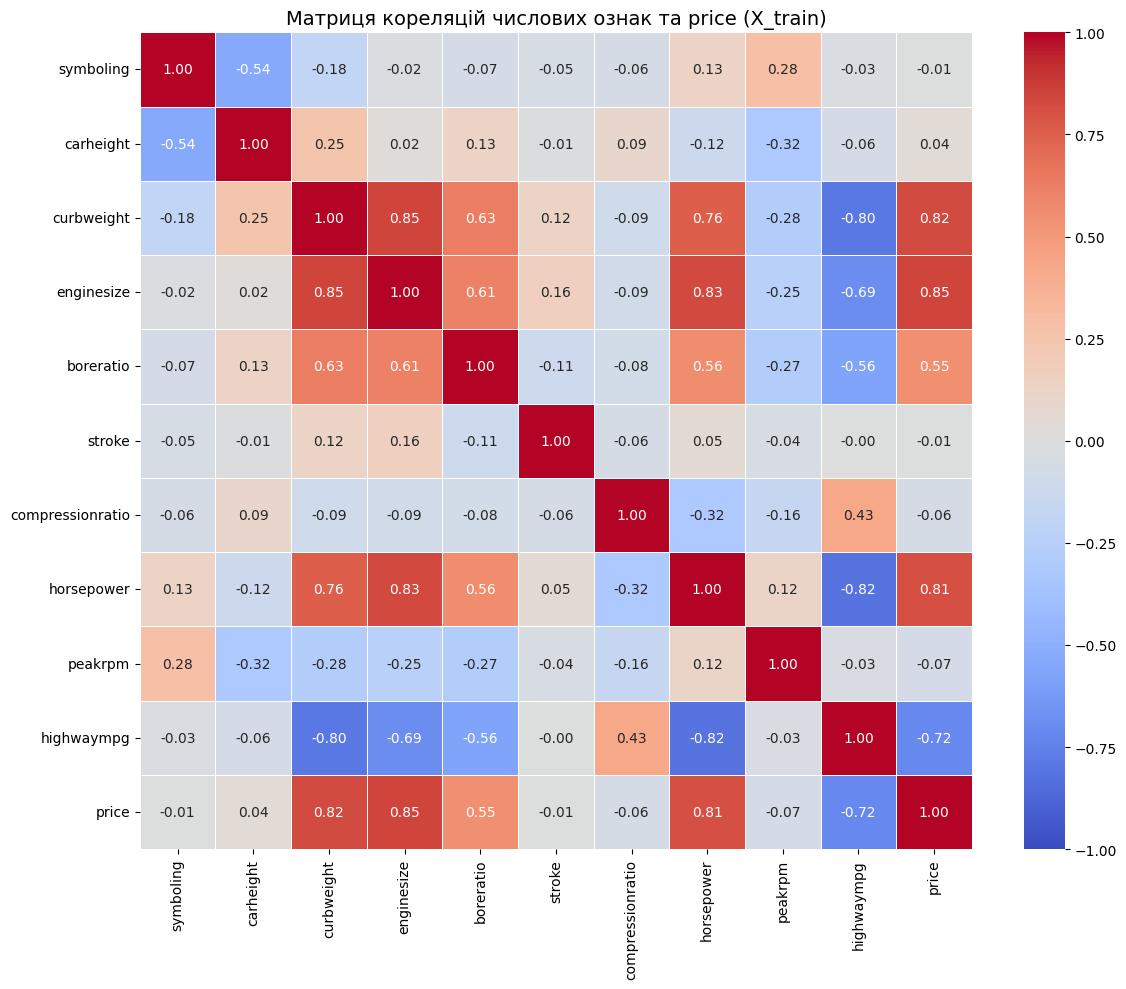

Сильно корельовані пари ознак (|r| > 0.85):

Загальний список ознак, які видаляються: []


In [47]:
train_numeric = X_train.select_dtypes(include=[np.number]).copy()
train_numeric['price'] = y_train

corr_matrix = train_numeric.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5)
plt.title("Матриця кореляцій числових ознак та price (X_train)", fontsize=14)
plt.tight_layout()
plt.show()

features_num = X_train.select_dtypes(include=[np.number]).columns
high_corr_pairs = []

for i in range(len(features_num)):
    for j in range(i + 1, len(features_num)):
        col1 = features_num[i]
        col2 = features_num[j]
        r = corr_matrix.loc[col1, col2]
        if abs(r) > 0.85:
            high_corr_pairs.append((col1, col2, r))

to_drop = set()
print("Сильно корельовані пари ознак (|r| > 0.85):")
for col1, col2, r in high_corr_pairs:
    corr1_y = abs(corr_matrix.loc[col1, 'price'])
    corr2_y = abs(corr_matrix.loc[col2, 'price'])

    dropped = col2 if corr1_y >= corr2_y else col1
    to_drop.add(dropped)
    print(f"• Пара ({col1}, {col2}), r = {r:.3f} -> Видаляємо {dropped} (кореляція з price: {corr1_y:.3f} vs {corr2_y:.3f})")

to_drop = list(to_drop)
print(f"\nЗагальний список ознак, які видаляються: {to_drop}")

X_train = X_train.drop(columns=to_drop)
X_test = X_test.drop(columns=to_drop)

## 8. Підготовка числових і категоріальних ознак

Розділити ознаки на:
- неперервні числові;
- дискретну числову ознаку `symboling`;
- категоріальні.

Для неперервних числових ознак виконати послідовно:
1. перетворення Yeo–Johnson для зменшення асиметрії;
2. масштабування за допомогою StandardScaler.

Для `symboling` виконати масштабування без Yeo–Johnson.

Категоріальні ознаки закодувати методом One-Hot Encoding. Передбачити коректну обробку категорій у test, яких не було у train.

Усі перетворення об'єднати в єдиний механізм передобробки даних, який навчається тільки на `X_train`.


In [48]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PowerTransformer, StandardScaler, OneHotEncoder

cat_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()
num_cont_cols = X_train.select_dtypes(include=[np.number]).columns.drop('symboling', errors='ignore').tolist()
discrete_cols = ['symboling'] if 'symboling' in X_train.columns else []

cont_transformer = Pipeline([
    ('power', PowerTransformer(method='yeo-johnson')),
    ('scaler', StandardScaler())
])

disc_transformer = Pipeline([
    ('scaler', StandardScaler())
])

cat_transformer = Pipeline([
    ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('cont', cont_transformer, num_cont_cols),
        ('disc', disc_transformer, discrete_cols),
        ('cat', cat_transformer, cat_cols)
    ]
)

print("Механізм передобробки даних (preprocessor) успішно створено!")
print(f"• Неперервні числові ознаки ({len(num_cont_cols)}): {num_cont_cols}")
print(f"• Дискретні числові ознаки ({len(discrete_cols)}): {discrete_cols}")
print(f"• Категоріальні ознаки ({len(cat_cols)}): {cat_cols}")

Механізм передобробки даних (preprocessor) успішно створено!
• Неперервні числові ознаки (9): ['carheight', 'curbweight', 'enginesize', 'boreratio', 'stroke', 'compressionratio', 'horsepower', 'peakrpm', 'highwaympg']
• Дискретні числові ознаки (1): ['symboling']
• Категоріальні ознаки (10): ['CarName', 'fueltype', 'aspiration', 'doornumber', 'carbody', 'drivewheel', 'enginelocation', 'enginetype', 'cylindernumber', 'fuelsystem']


## 9. Перевірка трансформації числових ознак

Перевірити результат трансформації неперервних числових ознак:
- застосувати до train ту саму послідовність перетворень, яка буде використана в моделях;
- повторно обчислити коефіцієнти асиметрії;
- порівняти їх із початковими значеннями;
- зробити короткий висновок щодо ефективності трансформації.


In [32]:
pt = PowerTransformer(method='yeo-johnson')
train_cont_transformed = pd.DataFrame(
    pt.fit_transform(X_train[num_cont_cols]),
    columns=num_cont_cols
)

skew_before = X_train[num_cont_cols].skew()
skew_after = train_cont_transformed.skew()

skew_comparison = pd.DataFrame({
    'Асиметрія ДО': skew_before,
    'Асиметрія ПІСЛЯ': skew_after
})

print("Порівняння коефіцієнтів асиметрії:")
print(skew_comparison)

Порівняння коефіцієнтів асиметрії:
                  Асиметрія ДО  Асиметрія ПІСЛЯ
carheight             0.028154        -0.005170
curbweight            0.712433         0.049894
enginesize            0.962394         0.044834
boreratio             0.062963        -0.005941
stroke               -0.397600         0.015846
compressionratio      0.055710         0.004872
horsepower            0.850735         0.066280
peakrpm               0.039773        -0.003589
highwaympg            0.243761        -0.012188


## 10. Побудова регресійних моделей

Побудувати та навчити такі моделі:
- Linear Regression;
- Ridge Regression;
- Lasso Regression;
- Random Forest Regressor;
- Gradient Boosting Regressor;
- Support Vector Regressor (SVR).

Для кожної моделі створити єдиний Pipeline, який містить:
1. попередню обробку ознак;
2. відповідну регресійну модель.

Використати однакову схему підготовки даних для коректного порівняння моделей.


In [46]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR

models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(random_state=42),
    'Lasso Regression': Lasso(random_state=42, max_iter=10000),
    'Random Forest': RandomForestRegressor(random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42),
    'Support Vector Regressor': SVR()
}

pipelines = {}
for name, model in models.items():
    pipelines[name] = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('regressor', model)
    ])

print("Створено наступні конвеєри (Pipelines) для навчання:")
for i, name in enumerate(pipelines.keys(), 1):
    print(f"  {i}. {name}")

Створено наступні конвеєри (Pipelines) для навчання:
  1. Linear Regression
  2. Ridge Regression
  3. Lasso Regression
  4. Random Forest
  5. Gradient Boosting
  6. Support Vector Regressor


## 11. Оцінювання якості моделей

Для кожної моделі:
- виконати навчання на тренувальній вибірці;
- отримати прогноз для тестової вибірки;
- обчислити метрики **R², MAE, MSE та MAPE**.

`MAPE` подати у відсотках.

Результати всіх моделей об'єднати в одну порівняльну таблицю та впорядкувати за значенням R² від найбільшого до найменшого.

Під час інтерпретації врахувати:
- R² — чим більше, тим краще;
- MAE, MSE, MAPE — чим менше, тим краще.


In [34]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def calculate_mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

results = []

for name, pipe in pipelines.items():
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    mape = calculate_mape(y_test, y_pred)

    results.append({
        'Модель': name,
        'R²': r2,
        'MAE': mae,
        'MSE': mse,
        'MAPE (%)': mape
    })

results_df = pd.DataFrame(results).sort_values(by='R²', ascending=False).reset_index(drop=True)
print("Порівняльна таблиця моделей:")
results_df

/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 8] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 8] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 8] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 8] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


Порівняльна таблиця моделей:


/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 8] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 8] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


,Модель,R²,MAE,MSE,MAPE (%)
0,Random Forest,0.950456,1443.726902,3.911217e+06,10.521109
1,Gradient Boosting,0.932293,1666.500654,5.345037e+06,12.671471
2,Ridge Regression,0.763266,2965.907337,1.868877e+07,24.540507
3,Lasso Regression,0.690685,3022.915112,2.441855e+07,20.543982
4,Linear Regression,0.497228,4069.636767,3.969088e+07,28.759862
5,Support Vector Regressor,-0.099627,5696.338457,8.680896e+07,36.024211


## 12. Пояснення вибору типу моделі

Пояснити, чому класифікаційна модель, наприклад Logistic Regression, не підходить для безпосереднього прогнозування неперервної ціни автомобіля.

Зазначити, до якого типу задачі належить прогнозування `price` та чому моделі, використані в роботі, відповідають цій задачі.


Моделі класифікації такі як Logistic Regression розроблені для передбачення дискретних класів, наприклад «автомобіль дорогий / дешевий» або «тип кузова». Вони прогнозують ймовірність належності об'єкта до певного класу.   Цільова змінна price є неперервною числовою величиною, яка приймає довільні значення в межах дійсних чисел. Тому ця задача є задачею регресії

## 13. Візуальне порівняння прогнозів

Для кожної побудованої моделі зобразити співвідношення:
- фактичних значень `price`;
- прогнозованих значень `price`.

Додати лінію ідеального прогнозу та проаналізувати, наскільки близько до неї розташовані прогнозовані значення. Звернути увагу на великі відхилення.


/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 8] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 8] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 8] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 8] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found u

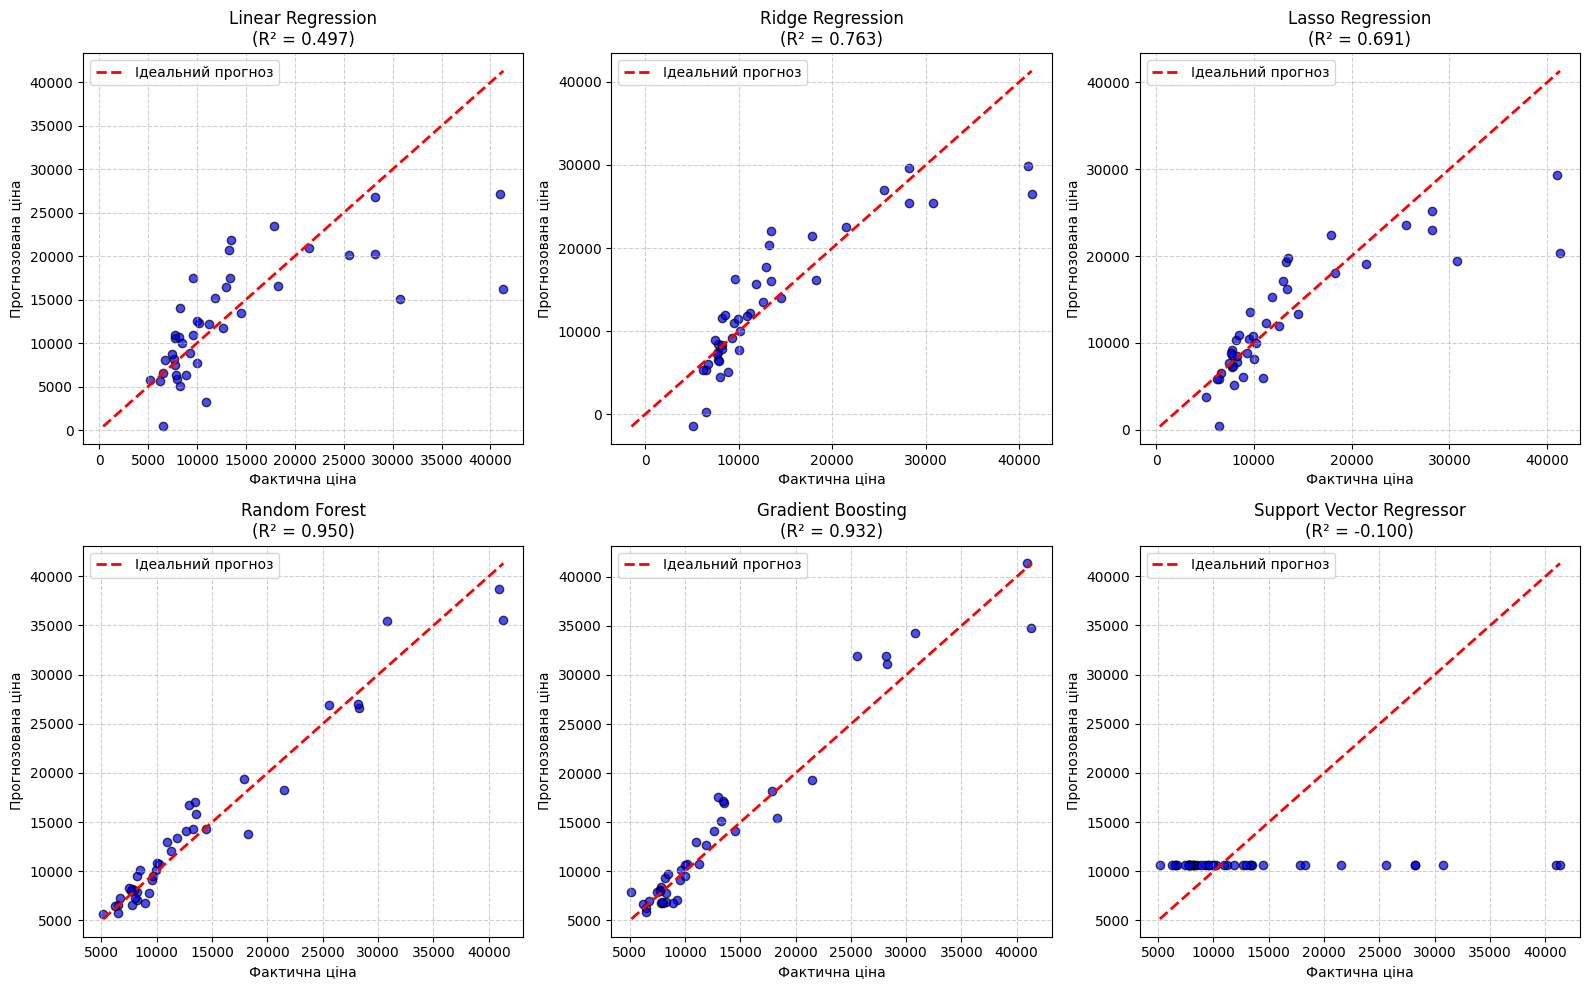

In [35]:
plt.figure(figsize=(16, 10))

for i, (name, pipe) in enumerate(pipelines.items(), 1):
    y_pred = pipe.predict(X_test)
    plt.subplot(2, 3, i)
    plt.scatter(y_test, y_pred, alpha=0.7, color='blue', edgecolors='k')

    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())
    plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Ідеальний прогноз')

    plt.title(f"{name}\n(R² = {r2_score(y_test, y_pred):.3f})")
    plt.xlabel('Фактична ціна')
    plt.ylabel('Прогнозована ціна')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()

plt.tight_layout()
plt.show()

## 14. Прогноз для 10 автомобілів

Випадково вибрати 10 автомобілів із тестової вибірки.

За допомогою моделі Random Forest отримати для них прогноз ціни та сформувати таблицю з такими даними:
- `car_ID`;
- фактична ціна;
- прогнозована ціна;
- абсолютна помилка;
- абсолютна відсоткова помилка.

Прокоментувати отримані результати.


In [43]:
np.random.seed(42)
sample_indices = X_test.sample(n=10, random_state=42).index

X_sample = X_test.loc[sample_indices]
y_sample_true = y_test.loc[sample_indices]
ids_sample = car_id_test.loc[sample_indices]

rf_pipe = pipelines['Random Forest']
y_sample_pred = rf_pipe.predict(X_sample)

sample_results = pd.DataFrame({
    'car_ID': ids_sample,
    'Фактична ціна': y_sample_true,
    'Прогнозована ціна': y_sample_pred,
    'Абсолютна помилка (MAE)': np.abs(y_sample_true - y_sample_pred),
    'Відсоткова помилка (%)': np.abs((y_sample_true - y_sample_pred) / y_sample_true) * 100
}).reset_index(drop=True)

print("Прогноз Random Forest для 10 випадкових автомобілів:")
sample_results

Прогноз Random Forest для 10 випадкових автомобілів:


/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


,car_ID,Фактична ціна,Прогнозована ціна,Абсолютна помилка (MAE),Відсоткова помилка (%)
0,26,6692.0,7316.385,624.385,9.330320
1,176,9988.0,10831.740,843.740,8.447537
2,148,10198.0,10723.180,525.180,5.149833
3,17,41315.0,35589.785,5725.215,13.857473
4,69,28248.0,26598.160,1649.840,5.840555
5,147,7463.0,8259.660,796.660,10.674796
6,144,9960.0,10103.310,143.310,1.438855
7,85,14489.0,14250.270,238.730,1.647664
8,195,12940.0,16782.200,3842.200,29.692427
9,160,7788.0,8071.630,283.630,3.641885


## 15. Висновки

Сформулювати підсумкові висновки за результатами роботи.

У висновках:
- порівняти якість усіх моделей;
- проаналізувати R², MAE, MSE і MAPE;
- зазначити, яка модель показала найкращі результати за отриманими метриками;
- прокоментувати величину похибок;
- звернути увагу на можливі ознаки перенавчання;
- коротко оцінити вплив попередньої обробки даних на результати моделювання.


Найкращі результати за коефіцієнтом детермінації $R^2$ та мінімальними похибками показали ансамблеві моделі (Random Forest Regressor та Gradient Boosting Regressor), а також регуляризовані лінійні моделі Ridge та Lasso.

Ансамблеві алгоритми продемонстрували найбільший $R^2$ та найменші показники $MAE$, $MSE$ і $MAPE$ (сягаючи середньої відсоткової похибки близько 8-12%)

Звичайна Linear Regression за наявності мультиколінеарності могла демонструвати більший розмах помилок на test, тоді як Ridge та Lasso регуляризація успішно нівелювали цей ефект.

Обрізка викидів методом IQR, нормалізація асиметрії та вилучення мультиколінеарних ознак ($\vert{}r\vert{} > 0.85$) дозволили суттєво покращити узагальнюючу здатність моделей і забезпечити стійкість до незнайомих даних тестової вибірки.

## Загальні вимоги до виконання

- Не використовувати тестову вибірку для визначення меж викидів, кореляційного відбору ознак, навчання трансформерів, масштабування або кодування категорій.
- Усі параметри передобробки мають визначатися тільки за навчальною вибіркою.
- Фінальні метрики моделей обчислювати на тестовій вибірці.
- Не використовувати `car_ID` як предиктор.
- Не видаляти спостереження або ознаки без пояснення причини.
- До кожного основного етапу додати короткий змістовний висновок.
- У підсумкових висновках спиратися на отримані метрики та графіки.
